In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

In [3]:
# Minimal RK4 step for scalars
def step_rk4(y, t, step, dy, **kwargs):
    y = float(y)
    half = step / 2.0
    k1 = dy(t, y, **kwargs)
    k2 = dy(t + half, y + k1 * half, **kwargs)
    k3 = dy(t + half, y + k2 * half, **kwargs)
    k4 = dy(t + step, y + k3 * step, **kwargs)
    return y + (step / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [4]:
import seaborn as sns
sns.set(style="whitegrid")


def pretty_plot_results(times, potentials, intensities, spikes, title="Simulation"):
    import numpy as _np
    times = _np.array(times)
    times_ms = times * 1000.0
    potentials = _np.array(potentials)
    intensities = _np.array(intensities)
    spikes = _np.array(spikes)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pal = sns.color_palette("deep")
    color_p = pal[0]
    color_i = pal[1]

    ax.plot(times_ms, potentials, color=color_p,
            lw=1.6, label="Membrane potential")
    ax.set_ylabel("Potential", color=color_p)
    ax.set_xlabel("Time (ms)")
    ax.tick_params(axis="y", labelcolor=color_p)

    ax2 = ax.twinx()
    ax2.fill_between(times_ms, intensities, color=color_i, alpha=0.25)
    ax2.plot(times_ms, intensities, color=color_i,
             lw=1.0, alpha=0.9, label="Intensity")
    ax2.set_ylabel("Intensity", color=color_i)
    ax2.tick_params(axis="y", labelcolor=color_i)

    # Plot spikes as vertical markers (raster-like) aligned to potential axis
    spike_times = times_ms[spikes.astype(
        bool)] if spikes.size else _np.array([])
    if spike_times.size > 0:
        ylim = ax.get_ylim()
        height = ylim[1] - ylim[0]
        line_y = ylim[0] + 0.85 * height
        ax.vlines(spike_times, line_y - 0.02 * height, line_y +
                  0.02 * height, color="red", alpha=0.9, linewidth=1.2)
        ax.scatter(spike_times, _np.ones_like(spike_times) * (line_y +
                   0.04 * height), color="red", s=18, zorder=5, label="Spikes")

    # Combined legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [5]:
STEP_SIZE = 1e-3  # s
SIMULATION_LENGTH = 1  # s
REFRACTORY_PERIOD = 5  # steps

times = np.arange(0, SIMULATION_LENGTH, STEP_SIZE)
delta_time = times[1] - times[0]
n_steps = times.shape[0]

In [6]:
# Membrane potential constants
TAU = 1  # ms
INVERSE_TAU = 1 / TAU
REST_POTENTIAL = 0  # V
RESISTANCE = 1  # ohm
SPIKE_THRESHOLD = 1.2  # V

# Current constants
TAU_SYNAPSE = 1  # ms

# Membrane threshold constants
THRESHOLD_TAU = 10  # s
THRESHOLD_DELTA = 5e-2


# Weight constants
# Same for potentiation and depression but usually made different for each
LEARNING_WINDWOW = 5e-3

# Same for potentiation and depression but usually made different for each
POTENTIATION = 0.01
BASE_CURRENT = 1


IMPULSE_FREQUENCY = 10
WINDOW_START = int(n_steps * 0.4)
WINDOW_END = int(n_steps * 0.6)

In [7]:
def derivative_potential(t, membrane_potential, input_signal):
    return (RESISTANCE * input_signal - (membrane_potential - REST_POTENTIAL)) * INVERSE_TAU


def spiked(v: float, threshold: float) -> bool:
    return v >= threshold


def spike_response(v: float, v_rest: float) -> float:
    return v_rest


def delta_weights(delta_times: float) -> float:
    return np.sign(delta_times) * POTENTIATION * np.exp(-1 * np.abs(delta_times/LEARNING_WINDWOW))

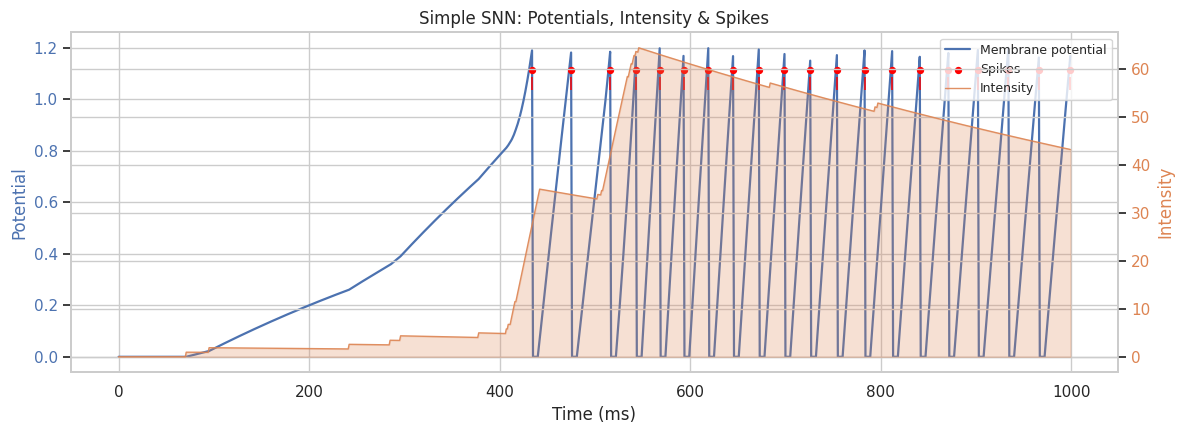

In [8]:

input_noise = np.random.normal(0, 0.1, size=times.shape)
input_impulse = 0.5 * np.sin(2 * np.pi * IMPULSE_FREQUENCY * times)
input_impulse[:WINDOW_START] = 0
input_impulse[WINDOW_END:] = 0

raw_signal = input_noise + input_impulse
signal_envelope = np.abs(hilbert(raw_signal))
theta = np.percentile(signal_envelope, 75)
spiked_signal = np.where(raw_signal > theta, 1, 0)
spiked_signal += np.where(-raw_signal > theta, -1, 0)

# plt.plot(raw_signal)
# plt.plot(signal_envelope)
# plt.scatter(times, spiked_signal)
# plt.show()


weight = 0.5

# Variable threshold voltages
spike_threshold = SPIKE_THRESHOLD

EPOCHS = 100

potentials = []
spikes = []
input_signals = []

for epoch in range(EPOCHS):

    potential = REST_POTENTIAL
    potentials = []
    postsynaptic_spike_time = 0
    presynaptic_spike_time = 0
    spike_cooldown = 0
    input_signal = 0
    input_signals = []
    spikes = []

    for i, t in enumerate(times):
        potentials.append(potential)

        input_signal *= np.exp(-delta_time/TAU_SYNAPSE)
        # spike_threshold *= np.exp(-delta_time/THRESHOLD_TAU)

        if spike := spiked_signal[i] == 1:
            presynaptic_spike_time = t
            input_signal += spike * weight

        input_signals.append(input_signal)

        if spike_cooldown > 0:
            spike_cooldown -= 1
            spikes.append(0)
            continue

        potential = step_rk4(potential, t, STEP_SIZE,
                             derivative_potential, input_signal=input_signals[i])

        if spiked(potential, spike_threshold):
            spikes.append(1)
            postsynaptic_spike_time = t
            potential = spike_response(potential, REST_POTENTIAL)

            spike_cooldown = REFRACTORY_PERIOD

            # update weights
            weight += delta_weights(postsynaptic_spike_time -
                                    presynaptic_spike_time)

            # spike_threshold += THRESHOLD_DELTA
        else:
            spikes.append(0)


# Use the new pretty plotting helper: convert times (s) to ms inside helper
pretty_plot_results(times, potentials, input_signals, spikes,
                    title="Simple SNN: Potentials, Intensity & Spikes")